# June 2025 European Heatwave Ensemble Reforecast

This notebook is an ensemble version of `heatwave-reforecast.ipynb` (deterministic). In order to compute the station-based ensemble Continuous Ranked Probability Score (CRPS), you need to the `ensemble` extra from the [stationbench fork](https://github.com/martibosch/stationbench) (e.g., `pip install "stationbench[ensemble] @ git+https://github.com/martibosch/stationbench.git"`).

In [ ]:
import datetime as dt
import os
import pathlib

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import stationbench
import xarray as xr
from stationbench.utils import regions

from aifs_modal_demo import ingest, tasks
from aifs_modal_demo.app import app, run_forecast

## Set up

In [ ]:
# experiment label
n_members = 10
experiment = "heatwave-2025-jun-ens"

# forecast window: init at heatwave onset for a clean 10-day medium/extended-range eval
start_date = dt.datetime(2025, 6, 20, 0, tzinfo=dt.UTC)
lead_time = 240  # in hours, i.e., until 2025-06-30 00 UTC
end_date = start_date + dt.timedelta(hours=lead_time)
print(f"Experiment : {experiment}")
print(f"Members    : {n_members}")
print(f"Start      : {start_date}")
print(f"End        : {end_date}  (T+{lead_time} h)")

# modal storage
storage_bucket = "aifs-modal"
initial_conditions_prefix = "aifs-initial-conditions"
initial_conditions_branch = "main"
outputs_prefix = "aifs-outputs-ens"
outputs_branch = experiment

# stationbench
region = "switzerland"
lat_slice = (44.5, 48.5)
lon_slice = (4.5, 11.5)
stationbench_dir = pathlib.Path("../data/stationbench")
stations_filepath = stationbench_dir / f"{experiment}-stations.nc"
era5_filepath = stationbench_dir / f"{experiment}-era5.nc"

# viz
figwidth = plt.rcParams["figure.figsize"][0]
figheight = plt.rcParams["figure.figsize"][1]

Experiment : heatwave-2025-jun-ens
Members    : 10
Start      : 2025-06-20 00:00:00+00:00
End        : 2025-06-30 00:00:00+00:00  (T+240 h)


## 1. Ingesting initial conditions

In [ ]:
initial_conditions_storage = icechunk.tigris_storage(
    bucket=storage_bucket,
    prefix=initial_conditions_prefix,
    region=os.getenv("AWS_REGION", None),
    access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)
initial_conditions_repo = icechunk.Repository.open_or_create(initial_conditions_storage)

for date in [start_date - dt.timedelta(hours=6), start_date]:
    ingest.ensure_date_ingested(
        date, initial_conditions_repo, branch=initial_conditions_branch
    )

  2026-03-12T18:23:54.103287Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1773200802324/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121

Initial conditions already ingested for 2025-06-19T18:00:00+00:00 (group: 2025-06-19/18z); skipping
Initial conditions already ingested for 2025-06-20T00:00:00+00:00 (group: 2025-06-20/00z); skipping


## 2. Running the ensemble reforecast on Modal

We check whether all ensemble members already exist to avoid re-running:

In [ ]:
# forecast outputs icechunk session
outputs_storage = icechunk.tigris_storage(
    bucket=storage_bucket,
    prefix=outputs_prefix,
    region=os.getenv("AWS_REGION", None),
    access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)
outputs_repo = icechunk.Repository.open_or_create(outputs_storage)

# check whether the branch and all ensemble members already exist
forecast_group = start_date.strftime("%Y-%m-%d/%Hz")
try:
    outputs_session = outputs_repo.readonly_session(outputs_branch)
    existing = xr.open_dataset(
        outputs_session.store,
        group=forecast_group,
        engine="zarr",
        zarr_format=3,
    )
    forecast_exists = existing.sizes.get("ensemble_member", 0) >= n_members
except Exception:
    forecast_exists = False

if not forecast_exists:
    # with modal.enable_output():  # uncomment for live logs
    with app.run():
        run_forecast.remote(
            start_date,
            storage_bucket,
            lead_time=lead_time,
            initial_conditions_prefix=initial_conditions_prefix,
            initial_conditions_branch=initial_conditions_branch,
            outputs_prefix=outputs_prefix,
            outputs_branch=outputs_branch,
            include_pressure_levels=False,
            n_members=n_members,
        )
    outputs_session = outputs_repo.readonly_session(outputs_branch)
else:
    print(f"All {n_members} members already exist for {forecast_group}; skipping")

  2026-03-12T18:24:07.403157Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1773200802324/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121



## 3. Loading ensemble forecast outputs

All members are stored in a single zarr group with an `ensemble_member` dimension:

In [ ]:
forecast_group = start_date.strftime("%Y-%m-%d/%Hz")
forecast_ds = xr.open_dataset(
    outputs_session.store,
    group=forecast_group,
    engine="zarr",
    zarr_format=3,
    chunks="auto",
)
print(
    f"{forecast_ds.sizes['ensemble_member']} members, "
    f"{forecast_ds.sizes['valid_time']} time steps"
)
forecast_ds

10 members, 40 time steps


/tmp/ipykernel_236274/3878728494.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 36. This could degrade performance. Instead, consider rechunking after loading.
  forecast_ds = xr.open_dataset(
/tmp/ipykernel_236274/3878728494.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 681. This could degrade performance. Instead, consider rechunking after loading.
  forecast_ds = xr.open_dataset(
/tmp/ipykernel_236274/3878728494.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 1366. This could degrade performance. Instead, consider rechunking after loading.
  forecast_ds = xr.open_dataset(


<xarray.Dataset> Size: 37GB
Dimensions:          (ensemble_member: 10, valid_time: 40, lat: 721, lon: 1440,
                      pressure: 13)
Coordinates:
  * ensemble_member  (ensemble_member) int64 80B 0 1 2 3 4 5 6 7 8 9
  * valid_time       (valid_time) datetime64[ns] 320B 2025-06-20T06:00:00 ......
  * lat              (lat) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * lon              (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * pressure         (pressure) int64 104B 50 100 150 200 ... 700 850 925 1000
Data variables: (12/22)
    10u              (ensemble_member, valid_time, lat, lon) float32 2GB dask.array<chunksize=(1, 36, 681, 1366), meta=np.ndarray>
    cp               (ensemble_member, valid_time, lat, lon) float32 2GB dask.array<chunksize=(1, 36, 681, 1366), meta=np.ndarray>
    hcc              (ensemble_member, valid_time, lat, lon) float32 2GB dask.array<chunksize=(1, 36, 681, 1366), meta=np.ndarray>
    10v              (ensemble_member, valid_time, lat, lon) float32 2GB dask.array<chunksize=(1, 36, 681, 1366), meta=np.ndarray>
    100u             (ensemble_member, valid_time, lat, lon) float32 2GB dask.array<chunksize=(1, 36, 681, 1366), meta=np.ndarray>
    2t               (ensemble_member, valid_time, lat, lon) float32 2GB dask.array<chunksize=(1, 36, 681, 1366), meta=np.ndarray>
    ...               ...
    stl2             (ensemble_member, valid_time, lat, lon) float32 2GB dask.array<chunksize=(1, 36, 681, 1366), meta=np.ndarray>
    strd             (ensemble_member, valid_time, lat, lon) float32 2GB dask.array<chunksize=(1, 36, 681, 1366), meta=np.ndarray>
    sp               (ensemble_member, valid_time, lat, lon) float32 2GB dask.array<chunksize=(1, 36, 681, 1366), meta=np.ndarray>
    tcc              (ensemble_member, valid_time, lat, lon) float32 2GB dask.array<chunksize=(1, 36, 681, 1366), meta=np.ndarray>
    tp               (ensemble_member, valid_time, lat, lon) float32 2GB dask.array<chunksize=(1, 36, 681, 1366), meta=np.ndarray>
    stl1             (ensemble_member, valid_time, lat, lon) float32 2GB dask.array<chunksize=(1, 36, 681, 1366), meta=np.ndarray>

## 4. Prepare AIFS ensemble dataset for stationbench

The stationbench library expects a dataset with dimensions `(time, prediction_timedelta, latitude, longitude)` and, for ensemble metrics like CRPS, a `member` dimension. We rename `ensemble_member` to `member` to match stationbench conventions:

In [ ]:
# get surface data
aifs_ds = forecast_ds.sel(pressure=1000).drop_vars("pressure")
# compute 10 m wind speed scalar
aifs_ds = aifs_ds.assign(**{"10si": np.sqrt(aifs_ds["10u"] ** 2 + aifs_ds["10v"] ** 2)})
# keep only stationbench variables
aifs_ds = aifs_ds[["2t", "10si"]]
# rename dims for stationbench: lat/lon and ensemble_member → member
aifs_ds = aifs_ds.rename(
    {"lat": "latitude", "lon": "longitude", "ensemble_member": "member"}
)
# replace valid_time with prediction_timedelta
init_time = np.datetime64(start_date.replace(tzinfo=None), "ns")
aifs_ds = aifs_ds.assign_coords(
    prediction_timedelta=forecast_ds.valid_time.values - init_time
).expand_dims({"time": [init_time]})
aifs_ds

<xarray.Dataset> Size: 3GB
Dimensions:               (time: 1, member: 10, valid_time: 40, latitude: 721,
                           longitude: 1440, prediction_timedelta: 40)
Coordinates:
  * time                  (time) datetime64[ns] 8B 2025-06-20
  * member                (member) int64 80B 0 1 2 3 4 5 6 7 8 9
  * valid_time            (valid_time) datetime64[ns] 320B 2025-06-20T06:00:0...
  * latitude              (latitude) float64 6kB 90.0 89.75 ... -89.75 -90.0
  * longitude             (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 320B 06:00:0...
Data variables:
    2t                    (time, member, valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(1, 1, 36, 681, 1366), meta=np.ndarray>
    10si                  (time, member, valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(1, 1, 36, 681, 1366), meta=np.ndarray>

## 5. Fetching MeteoSwiss station data

In order to benchmark the AIFS forecast with station measurements, we use [meteora](https://github.com/martibosch/meteora) to download hourly temperature and wind-speed observations from MeteoSwiss automatic stations and convert the data into the stationbench input format (skipped automatically if already done):

In [ ]:
if not stations_filepath.exists():
    tasks.meteoswiss_stationbench(
        start_date, end_date, lat_slice, lon_slice, stations_filepath
    )
else:
    print(f"{stations_filepath} already exists; skipping")
ts_ds = xr.open_dataset(stations_filepath)
ts_ds

<xarray.Dataset> Size: 4MB
Dimensions:         (time: 1441, station_id: 157)
Coordinates:
  * time            (time) datetime64[ns] 12kB 2025-06-20 ... 2025-06-30
  * station_id      (station_id) <U3 2kB 'ABO' 'AEG' 'AIG' ... 'WFJ' 'WYN' 'ZER'
    longitude       (station_id) float64 1kB ...
    latitude        (station_id) float64 1kB ...
Data variables:
    2m_temperature  (time, station_id) float64 2MB ...
    10m_wind_speed  (time, station_id) float64 2MB ...

## 6. Compute AIFS ensemble verification metrics

We now use `stationbench.calculate_metrics`, which interpolates the gridded AIFS forecast to the MeteoSwiss station locations and computes RMSE, MBE, and **CRPS** per station and per lead-time step for each variable. The CRPS metric evaluates the quality of the full ensemble distribution, not just the ensemble mean:

In [ ]:
# add Switzerland region to stationbench if not already present
if region not in regions.region_dict:
    regions.add_region(region, lat_slice, lon_slice)
# compute stationbench metrics for AIFS forecast
metrics_ds = stationbench.calculate_metrics(
    forecast=aifs_ds,
    stations=ts_ds,
    start_date=start_date.strftime("%Y-%m-%d"),
    end_date=end_date.strftime("%Y-%m-%d"),
    region=region,
    name_2m_temperature="2t",
    name_10m_wind_speed="10si",
)
# exclude RMSE (maybe it would make sense to compute over the ensemble mean to compare
# with the deterministic case)
# TODO: stationbench-compatible approach to compute a subset of metrics only
metrics_ds = metrics_ds.sel(metric=["crps", "mbe"])
# show the dataset
metrics_ds

<xarray.Dataset> Size: 80MB
Dimensions:         (member: 10, station_id: 157, lead_time: 40, metric: 2,
                     valid_time: 40)
Coordinates:
  * member          (member) int64 80B 0 1 2 3 4 5 6 7 8 9
  * station_id      (station_id) <U3 2kB 'ABO' 'AEG' 'AIG' ... 'WFJ' 'WYN' 'ZER'
    latitude        (station_id) float64 1kB 46.49 47.13 46.33 ... 47.26 46.03
    longitude       (station_id) float64 1kB 7.561 8.608 6.924 ... 7.787 7.752
  * lead_time       (lead_time) timedelta64[ns] 320B 0 days 06:00:00 ... 10 d...
  * metric          (metric) object 16B 'crps' 'mbe'
Dimensions without coordinates: valid_time
Data variables:
    2m_temperature  (metric, member, valid_time, station_id, lead_time) float64 40MB ...
    10m_wind_speed  (metric, member, valid_time, station_id, lead_time) float64 40MB ...

We can now compute the MBE, and CRPS averaged across all stations for the medium-range (days 1-7) and extended-range (days 7-10) bins:

In [ ]:
bins = {
    "days 1-7": (np.timedelta64(1, "D"), np.timedelta64(7, "D")),
    "days 7-10": (np.timedelta64(7, "D"), np.timedelta64(10, "D")),
}

rows = []
for label, (t0, t1) in bins.items():
    row = {"bin": f"AIFS-ENS {label}"}
    for metric_name in metrics_ds.metric.values:
        val = (
            metrics_ds["2m_temperature"]
            .sel(metric=metric_name, lead_time=slice(t0, t1))
            .mean()
            .item()
        )
        col = f"{metric_name.upper()} (K)"
        row[col] = val
    rows.append(row)

pd.DataFrame(rows).set_index("bin")

,CRPS (K),MBE (K)
bin,,
AIFS-ENS days 1-7,4.599389,-0.923570
AIFS-ENS days 7-10,4.930529,-1.892909


Station-mean metrics as a function of lead time, including CRPS:

In [ ]:
for metric_name in metrics_ds.metric.values:
    df = metrics_ds.drop_vars(["latitude", "longitude"]).sel(
        metric=metric_name, drop=True
    )
    break
df

<xarray.Dataset> Size: 40MB
Dimensions:         (member: 10, station_id: 157, lead_time: 40, valid_time: 40)
Coordinates:
  * member          (member) int64 80B 0 1 2 3 4 5 6 7 8 9
  * station_id      (station_id) <U3 2kB 'ABO' 'AEG' 'AIG' ... 'WFJ' 'WYN' 'ZER'
  * lead_time       (lead_time) timedelta64[ns] 320B 0 days 06:00:00 ... 10 d...
Dimensions without coordinates: valid_time
Data variables:
    2m_temperature  (member, valid_time, station_id, lead_time) float64 20MB ...
    10m_wind_speed  (member, valid_time, station_id, lead_time) float64 20MB ...

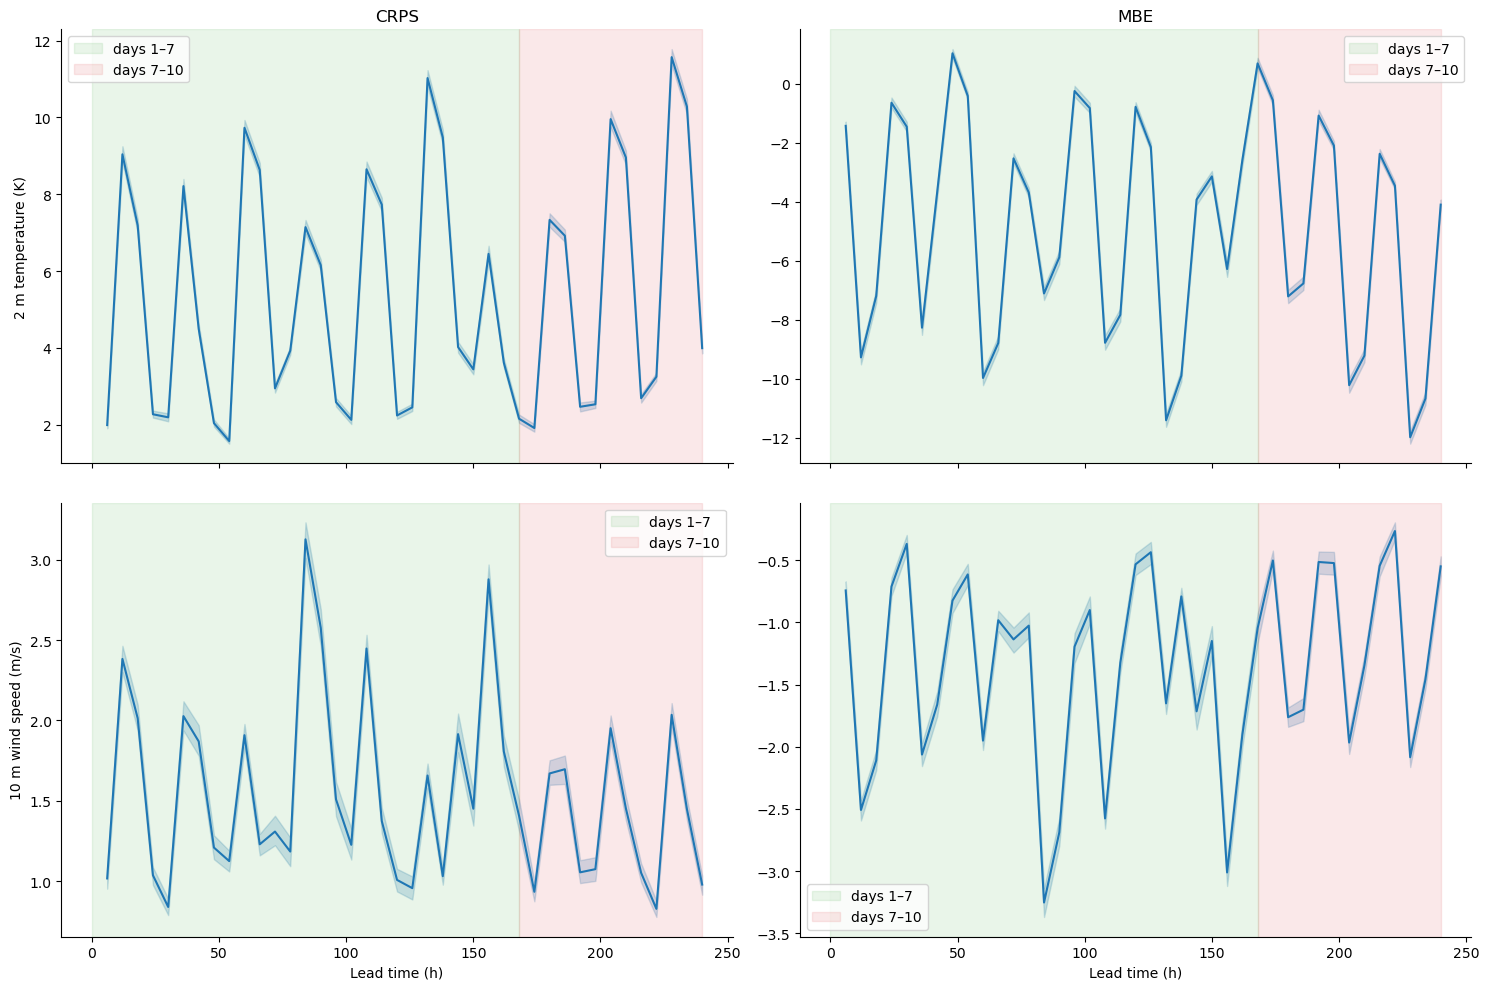

In [ ]:
# plot args
aspect = 1.5
lead_time_label = "Lead time (h)"
medium_color = sns.color_palette()[2]
extended_color = sns.color_palette()[3]
alpha = 0.1

# get long metrics data frame for seaborn
# 1. drop longitude/latitude
# 2. reduce parallel valid_time/lead_time to lead_time only
# 3. convert to pandas data frame
plot_df = (
    metrics_ds.drop_vars(["latitude", "longitude"])
    # .sel(metric=metric, drop=True)
    .isel(valid_time=xr.DataArray(range(len(metrics_ds.valid_time)), dims="valid_time"))
    .isel(valid_time=0, drop=True)
    .to_dataframe()
    .reset_index()
)
# 4. convert lead time to hours (int) and rename it for a nicer label
plot_df[lead_time_label] = (plot_df["lead_time"] / np.timedelta64(1, "h")).astype(int)
plot_df = plot_df.drop(columns=["lead_time"])
# 5. stack variables
plot_df = plot_df.melt(
    id_vars=plot_df.columns.drop(metrics_ds.data_vars), value_vars=metrics_ds.data_vars
)
# 6. nicer labels
plot_df["metric"] = plot_df["metric"].str.upper()
plot_df["variable"] = plot_df["variable"].map(
    {"2m_temperature": "2 m temperature (K)", "10m_wind_speed": "10 m wind speed (m/s)"}
)
# seaborn plot
g = sns.relplot(
    data=plot_df,
    x=lead_time_label,
    y="value",
    row="variable",
    col="metric",
    kind="line",
    facet_kws=dict(sharey=False),
    aspect=aspect,
)
# tweakings
# 1. rectangle for medium/extended ranges
for ax in g.axes.flat:
    ax.axvspan(0, 7 * 24, alpha=alpha, color=medium_color, label="days 1–7")
    ax.axvspan(7 * 24, 10 * 24, alpha=alpha, color=extended_color, label="days 7–10")
    ax.legend()
# 2. column titles
for ax, col_name in zip(g.axes[0], g.col_names):
    ax.set_title(col_name)
for ax in g.axes[1]:
    ax.set_title(None)
# 3. row titles
for ax, row_name in zip(g.axes[:, 0], g.row_names):
    ax.set_ylabel(row_name)

Station-level 2 m temperature CRPS maps averaged over medium/extended-range bins:

Text(0.5, 0.98, 'Station-level 2 m temperature CRPS (start: 2025-06-20 00:00:00)')

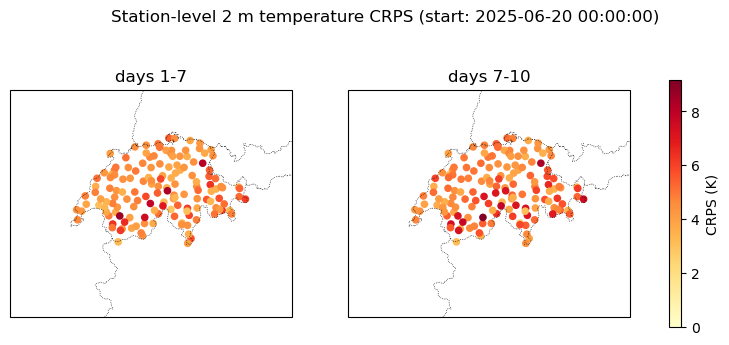

In [ ]:
bins_dict = {
    "days 1-7": (np.timedelta64(24, "h"), np.timedelta64(7 * 24, "h")),
    "days 7-10": (np.timedelta64(7 * 24, "h"), np.timedelta64(10 * 24, "h")),
}

# plot args
# metric to plot
metric = "crps"
cmap = "YlOrRd"

# reduce all non-station dims: lead_time, valid_time (if present), member (if present)
plot_da = xr.concat(
    [
        metrics_ds["2m_temperature"]
        .sel(metric=metric, lead_time=slice(t0, t1))
        .mean(["lead_time", "valid_time", "member"])
        for t0, t1 in bins_dict.values()
    ],
    dim=pd.Index(list(bins_dict.keys()), name="bin"),
).rename(f"{metric.upper()} (K)")

proj = ccrs.LambertConformal(central_longitude=8)
extent = [*lon_slice, *lat_slice]
# vmax = float(plot_da.quantile(0.95))
norm = plt.Normalize(vmin=0, vmax=plot_da.max())

# plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={"projection": proj})
for ax, bin_label in zip(axes, bins_dict):
    ax.scatter(
        plot_da.longitude.values,
        plot_da.latitude.values,
        c=plot_da.sel(bin=bin_label).values,
        cmap=cmap,
        norm=norm,
        s=20,
        transform=ccrs.PlateCarree(),
    )
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(bin_label)

fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    label=f"{metric.upper()} (K)",
    shrink=0.8,
)
fig.suptitle(
    f"Station-level 2 m temperature {metric.upper()} "
    f"(start: {start_date.replace(tzinfo=None)})",
)

We conclude by plotting the 2 m temperature time series at a selected MeteoSwiss station, showing: 
- AIFS individual members and ensemble mean with percentile envelope
- the selected station's observations
- the ERA5 reference data

Note that this plot can take a while because `forecast_ds["2t"]` is chunked by ensembles.

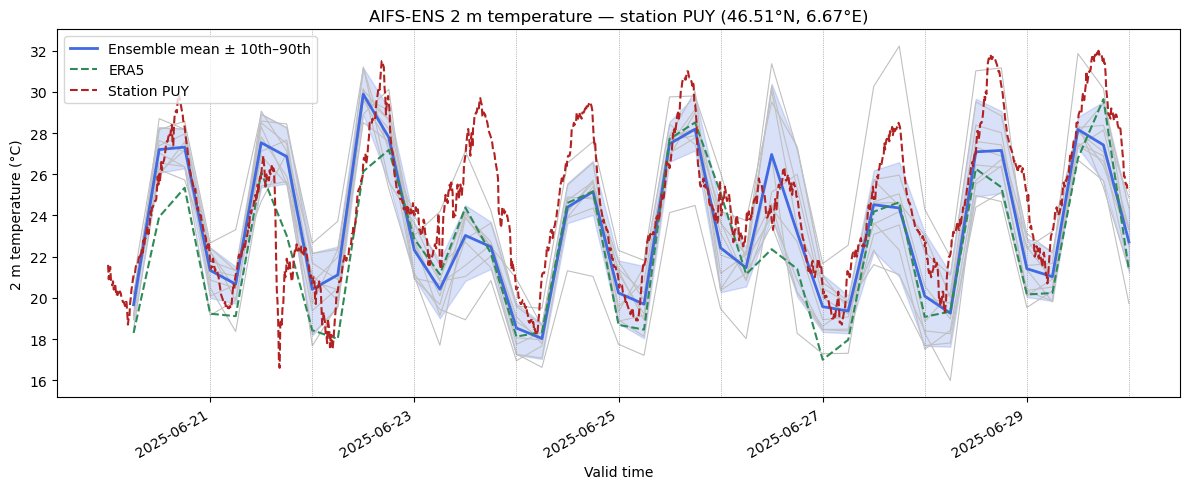

In [ ]:
station_id = "PUY"  # Pully, next to Lausanne

# station coordinates
stn_lat = float(ts_ds.latitude.sel(station_id=station_id))
stn_lon = float(ts_ds.longitude.sel(station_id=station_id))

# extract 2t at nearest grid point for all members, convert to °C
t2m_da = (
    forecast_ds["2t"].sel(lat=stn_lat, lon=stn_lon % 360, method="nearest") - 273.15
)

# ensemble long-form dataframe
# ACHTUNG: this is the expensive operation because it is where `compute` happens
ens_df = t2m_da.to_dataframe(name="2t").reset_index()

# station observations
obs_da = ts_ds["2m_temperature"].sel(station_id=station_id) - 273.15
obs_df = (
    obs_da.to_dataframe(name="2t").reset_index().rename(columns={"time": "valid_time"})
)

# get ERA5 reference
if not era5_filepath.exists():
    tasks.era5_stationbench(start_date, lead_time, era5_filepath)
else:
    print(f"{era5_filepath} already exists; skipping")
era5_ds = xr.open_dataset(era5_filepath)
era5_da = (
    era5_ds["2t"]
    .sel(latitude=stn_lat, longitude=stn_lon % 360, method="nearest")
    .isel(time=0)
    - 273.15
)
era5_valid_time = start_date + pd.to_timedelta(era5_da.prediction_timedelta.values)
era5_df = pd.DataFrame({"valid_time": era5_valid_time, "2t": era5_da.values})

# plot
fig, ax = plt.subplots(figsize=(12, 5))

# individual members (thin silver lines)
sns.lineplot(
    data=ens_df,
    x="valid_time",
    y="2t",
    units="ensemble_member",
    estimator=None,
    color="silver",
    linewidth=0.8,
    ax=ax,
)
# ensemble mean + 10th–90th CI (blue)
sns.lineplot(
    data=ens_df,
    x="valid_time",
    y="2t",
    estimator="mean",
    errorbar=("pi", 80),
    color="royalblue",
    linewidth=2,
    label="Ensemble mean ± 10th–90th",
    ax=ax,
)
# ERA5 (green dashed)
sns.lineplot(
    data=era5_df,
    x="valid_time",
    y="2t",
    color="seagreen",
    linewidth=1.5,
    linestyle="--",
    label="ERA5",
    ax=ax,
)
# station observations (red dashed)
sns.lineplot(
    data=obs_df,
    x="valid_time",
    y="2t",
    color="firebrick",
    linewidth=1.5,
    linestyle="--",
    label=f"Station {station_id}",
    ax=ax,
)

# final tweakings
# 24h vertical lines
for h in range(24, lead_time + 1, 24):
    ax.axvline(
        start_date + dt.timedelta(hours=h), color="grey", linestyle=":", linewidth=0.5
    )

# labels/titles
ax.set_ylabel("2 m temperature (°C)")
ax.set_xlabel("Valid time")
ax.set_title(
    f"AIFS-ENS 2 m temperature — station {station_id} "
    f"({stn_lat:.2f}°N, {stn_lon:.2f}°E)"
)
# legend
ax.legend()
# axis formatting for dates
fig.autofmt_xdate()
# tight layout
fig.tight_layout()